In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from function.library import *

from interpret.glassbox import ExplainableBoostingClassifier

In [2]:
X_train = pd.read_csv('../data/X_train.csv')   
y_train = pd.read_csv('../data/y_train.csv').values.ravel()
X_test = pd.read_csv('../data/X_test.csv')
y_test = pd.read_csv('../data/y_test.csv').values.ravel()

In [3]:
X_tune, _, y_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=100000,
    stratify=y_train,
    random_state=42
)

print("Tuning Shape:", X_tune.shape)
print("Tuning Distribution:")
print(pd.Series(y_tune).value_counts())

Tuning Shape: (100000, 23)
Tuning Distribution:
1.0    50000
0.0    50000
Name: count, dtype: int64


In [ ]:

default_ebm = ExplainableBoostingClassifier()

default_params = default_ebm.get_params()

default_params_df = pd.DataFrame(
    list(default_params.items()),
    columns=["Parameter", "Default Value"]
)

default_params_df

,Parameter,Default Value
0,callback,None
1,cat_smooth,10.0
2,cyclic_progress,False
3,early_stopping_rounds,100
4,early_stopping_tolerance,0.00001
5,exclude,None
6,feature_names,None
7,feature_types,None
8,gain_scale,5.0
9,greedy_ratio,10.0


In [5]:
important_params = [
    "max_bins",
    "learning_rate",
    "max_leaves",
    "interactions",
    "smoothing_rounds",
    "outer_bags",
    "inner_bags",
    "max_rounds",
    "early_stopping_rounds",
    "early_stopping_tolerance"
]

important_default_params = {
    param: default_params[param]
    for param in important_params
}

important_default_params_df = pd.DataFrame(
    important_default_params.items(),
    columns=["Parameter", "Default Value"]
)

display(important_default_params_df)

,Parameter,Default Value
0,max_bins,1024
1,learning_rate,0.015
2,max_leaves,2
3,interactions,3x
4,smoothing_rounds,75
5,outer_bags,14
6,inner_bags,0
7,max_rounds,50000
8,early_stopping_rounds,100
9,early_stopping_tolerance,0.00001


In [ ]:

ebm = ExplainableBoostingClassifier(
    random_state=42,
    n_jobs=-2
)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [22]:
# Level 1 grid search
level1_param_grid = {
    "learning_rate": [0.005,0.015,0.03],
    "max_leaves": [2,3],
    "smoothing_rounds": [50,75,100],
    "interactions": ["2x", "3x", "4x"]
}

level1_grid = GridSearchCV(
    estimator=ebm,
    param_grid=level1_param_grid,
    scoring="roc_auc",
    cv=skf,
    n_jobs=1,
    verbose=2,
    return_train_score=True
)

level1_start_time = time.time()

level1_grid.fit(
    X_tune,
    y_tune
)

level1_time = (
    time.time()
    - level1_start_time
)

print("Level 1 Best Parameters:")
print(level1_grid.best_params_)

print("\nLevel 1 Best Mean CV ROC-AUC:")
print(level1_grid.best_score_)

print(
    "\nLevel 1 Tuning Time:",
    f"{level1_time:.2f} seconds"
)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
[CV] END interactions=2x, learning_rate=0.005, max_leaves=2, smoothing_rounds=50; total time=18.7min
[CV] END interactions=2x, learning_rate=0.005, max_leaves=2, smoothing_rounds=50; total time=18.7min
[CV] END interactions=2x, learning_rate=0.005, max_leaves=2, smoothing_rounds=50; total time=18.6min
[CV] END interactions=2x, learning_rate=0.005, max_leaves=2, smoothing_rounds=50; total time=19.4min
[CV] END interactions=2x, learning_rate=0.005, max_leaves=2, smoothing_rounds=50; total time=20.4min
[CV] END interactions=2x, learning_rate=0.005, max_leaves=2, smoothing_rounds=75; total time=19.5min
[CV] END interactions=2x, learning_rate=0.005, max_leaves=2, smoothing_rounds=75; total time=18.3min
[CV] END interactions=2x, learning_rate=0.005, max_leaves=2, smoothing_rounds=75; total time=18.6min
[CV] END interactions=2x, learning_rate=0.005, max_leaves=2, smoothing_rounds=75; total time=18.2min
[CV] END interactions=2x, lea

In [23]:
best_level1_params = (
    level1_grid.best_params_
)

best_level1_params

{'interactions': '2x',
 'learning_rate': 0.03,
 'max_leaves': 3,
 'smoothing_rounds': 50}

In [ ]:

best_learning_rate = best_level1_params["learning_rate"]

if best_learning_rate == 0.005:
    learning_rate_values = [0.0025, 0.005, 0.01]

elif best_learning_rate == 0.015:
    learning_rate_values = [0.01, 0.015, 0.02]

else:
    learning_rate_values = [0.02, 0.03, 0.04]

best_max_leaves = best_level1_params["max_leaves"]

if best_max_leaves == 2:
    max_leaves_values = [2, 3]

else:
    max_leaves_values = [3, 4]


best_smoothing_rounds = best_level1_params["smoothing_rounds"]

if best_smoothing_rounds == 50:
    smoothing_rounds_values = [25, 50, 75]

elif best_smoothing_rounds == 75:
    smoothing_rounds_values = [50, 75, 100]

else:
    smoothing_rounds_values = [75, 100, 125]

best_interactions = best_level1_params["interactions"]

if best_interactions == "2x":
    interactions_values = ["1.5x", "2x", "2.5x"]

elif best_interactions == "3x":
    interactions_values = ["2.5x", "3x", "3.5x"]

else:
    interactions_values = ["3.5x", "4x", "4.5x"]

level2_param_grid = {
    "learning_rate": learning_rate_values,
    "max_leaves": max_leaves_values,
    "smoothing_rounds": smoothing_rounds_values,
    "interactions": interactions_values
}

print("Level 2 Parameter Grid:")
print(level2_param_grid)

Level 2 Parameter Grid:
{'learning_rate': [0.02, 0.03, 0.04], 'max_leaves': [3, 4], 'smoothing_rounds': [25, 50, 75], 'interactions': ['1.5x', '2x', '2.5x']}


In [ ]:

level2_grid = GridSearchCV(
    estimator=ebm,
    param_grid=level2_param_grid,
    scoring="roc_auc",
    cv=skf,
    n_jobs=1,
    verbose=2,
    return_train_score=True
)

level2_start_time = time.time()

level2_grid.fit(
    X_tune,
    y_tune
)

level2_time = (
    time.time()
    - level2_start_time
)

print("Level 2 Best Parameters:")
print(level2_grid.best_params_)

print("\nLevel 2 Best Mean CV ROC-AUC:")
print(level2_grid.best_score_)

print(
    "\nLevel 2 Tuning Time:",
    f"{level2_time:.2f} seconds"
)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
[CV] END interactions=1.5x, learning_rate=0.02, max_leaves=3, smoothing_rounds=25; total time= 1.3min
[CV] END interactions=1.5x, learning_rate=0.02, max_leaves=3, smoothing_rounds=25; total time= 1.3min
[CV] END interactions=1.5x, learning_rate=0.02, max_leaves=3, smoothing_rounds=25; total time= 1.2min
[CV] END interactions=1.5x, learning_rate=0.02, max_leaves=3, smoothing_rounds=25; total time= 1.2min
[CV] END interactions=1.5x, learning_rate=0.02, max_leaves=3, smoothing_rounds=25; total time= 1.1min
[CV] END interactions=1.5x, learning_rate=0.02, max_leaves=3, smoothing_rounds=50; total time= 1.3min
[CV] END interactions=1.5x, learning_rate=0.02, max_leaves=3, smoothing_rounds=50; total time= 1.5min
[CV] END interactions=1.5x, learning_rate=0.02, max_leaves=3, smoothing_rounds=50; total time= 1.5min
[CV] END interactions=1.5x, learning_rate=0.02, max_leaves=3, smoothing_rounds=50; total time= 1.3min
[CV] END interaction

In [ ]:

ebm_best_parameters_df = pd.DataFrame([
    {
        "Search Level": "Level 1",
        **level1_grid.best_params_,
        "Best Mean CV ROC-AUC": level1_grid.best_score_,
        "Tuning Time": level1_time
    },
    {
        "Search Level": "Level 2",
        **level2_grid.best_params_,
        "Best Mean CV ROC-AUC": level2_grid.best_score_,
        "Tuning Time": level2_time
    }
])

ebm_best_parameters_df.to_csv(
    "../results/ebm_best_parameters.csv",
    index=False
)

print("Level 1 and Level 2 best parameters saved successfully.")

ebm_best_parameters_df

Level 1 and Level 2 best parameters saved successfully.


,Search Level,interactions,learning_rate,max_leaves,smoothing_rounds,Best Mean CV ROC-AUC,Tuning Time
0,Level 1,2x,0.03,3,50,0.978201,159715.627256
1,Level 2,1.5x,0.04,3,25,0.978269,16572.872904


In [ ]:

best_level2_params = (
    level2_grid.best_params_
)

best_ebm = ExplainableBoostingClassifier(
    max_bins=1024,
    learning_rate= best_level2_params["learning_rate"],
    max_leaves= best_level2_params["max_leaves"],
    smoothing_rounds= best_level2_params["smoothing_rounds"],
    interactions= best_level2_params["interactions"],
    random_state=42,
    n_jobs=-2
)

final_start_time = time.time()

best_ebm.fit(
    X_train,
    y_train
)

final_training_time = (
    time.time()
    - final_start_time
)

print(
    "Final EBM Training Time:",
    f"{final_training_time:.2f} seconds"
)

Final EBM Training Time: 1852.55 seconds


In [ ]:

final_y_pred = best_ebm.predict(X_test)
final_y_prob = best_ebm.predict_proba(X_test)[:, 1]

y_test_clean = (pd.Series(y_test).astype(float).astype(int))
final_y_pred = (pd.Series(final_y_pred).astype(float).astype(int))
final_y_prob = np.asarray(final_y_prob,dtype=float)

In [ ]:

ebm_metrics = {
    "Accuracy": accuracy_score(y_test_clean,final_y_pred),
    "Precision": precision_score(y_test_clean,final_y_pred),
    "Recall": recall_score(y_test_clean,final_y_pred),
    "F1 Score": f1_score(y_test_clean,final_y_pred),
    "ROC-AUC": roc_auc_score(y_test_clean,final_y_prob),
    "Log Loss": log_loss(y_test_clean,final_y_prob),
    "Brier Score": brier_score_loss(y_test_clean,final_y_prob),
    "Training Time":final_training_time
}

ebm_results_df = pd.DataFrame(
    list(
        ebm_metrics.items()
    ),
    columns=["Metric","EBM"]
)

ebm_results_df

,Metric,EBM
0,Accuracy,0.907987
1,Precision,0.914862
2,Recall,0.975475
3,F1 Score,0.944197
4,ROC-AUC,0.926530
5,Log Loss,0.239443
6,Brier Score,0.070035
7,Training Time,1852.550220


In [ ]:

joblib.dump(
    best_ebm,
    "../models/ebm_model.pkl"
)

ebm_results_df.to_csv(
    "../results/ebm_evaluation_results.csv",
    index=False
)

print("Final EBM model and evaluation results saved successfully.")

Final EBM model and evaluation results saved successfully.


In [ ]:
feature_importance_df = pd.DataFrame({
    "Term":
        best_ebm.term_names_,

    "Importance":
        best_ebm.term_importances()
})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

feature_importance_df.to_csv(
    "../results/ebm_feature_importance.csv",
    index=False
)

feature_importance_df

,Term,Importance
0,grade_subgrade,2.938352
1,debt_to_income_ratio,2.055398
2,credit_score,2.028129
3,employment_status_Unemployed,1.981731
4,employment_status_Student,0.276630
5,interest_rate,0.269461
6,education_level,0.225950
7,loan_amount,0.188772
8,credit_score & employment_status_Unemployed,0.163467
9,annual_income,0.161209


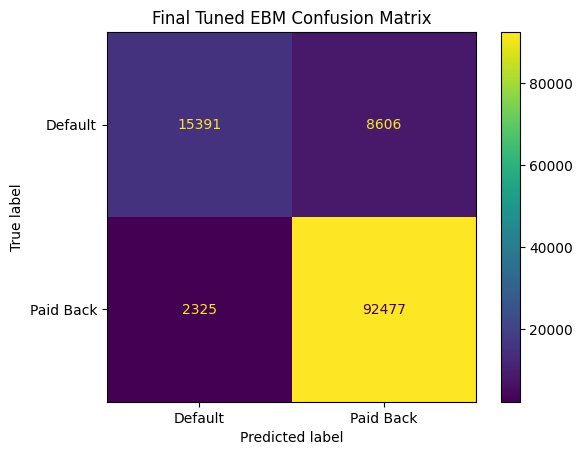

In [ ]:

cm = confusion_matrix(
    y_test_clean,
    final_y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Default",
        "Paid Back"
    ]
)

disp.plot()

plt.title(
    "Final Tuned EBM Confusion Matrix"
)

plt.show()

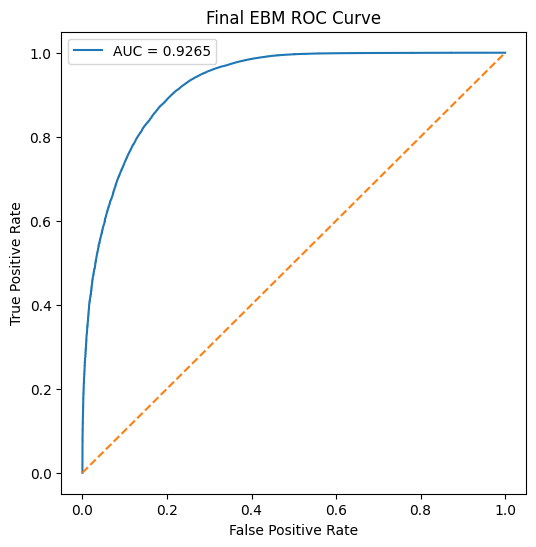

In [ ]:

fpr, tpr, _ = roc_curve(
    y_test_clean,
    final_y_prob
)

plt.figure(
    figsize=(6, 6)
)

plt.plot(
    fpr,
    tpr,
    label=(
        f"AUC = "
        f"{roc_auc_score(y_test_clean, final_y_prob):.4f}"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    "--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Final EBM ROC Curve"
)

plt.legend()

plt.show()

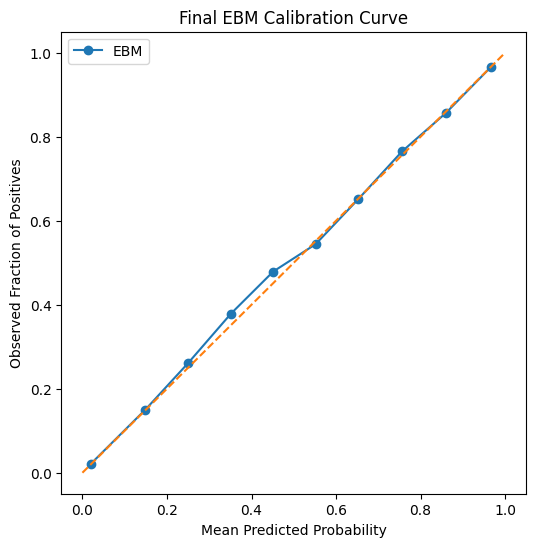

In [ ]:

prob_true, prob_pred = calibration_curve(
    y_test_clean,
    final_y_prob,
    n_bins=10
)

plt.figure(
    figsize=(6, 6)
)

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="EBM"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--"
)

plt.xlabel(
    "Mean Predicted Probability"
)

plt.ylabel(
    "Observed Fraction of Positives"
)

plt.title(
    "Final EBM Calibration Curve"
)

plt.legend()

plt.show()